# Numbeo Healthcare: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

## 1. Loading the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import math
import plotly

import warnings
warnings.simplefilter('ignore')

import numpy as np
from scipy import stats

def load_numbeo_file(filepath):
    all_years = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        try:
            df = pd.read_excel(filepath, sheet_name=sheet)
            df['year'] = int(str(sheet).strip())
            all_years.append(df)
            print(f'✓ Loaded sheet: {sheet} — {len(df)} rows')
        except Exception as e:
            print(f'✗ Skipped sheet: {sheet} — {e}')
    return pd.concat(all_years, ignore_index=True)

df = load_numbeo_file('../data/raw/numbeo_health_care_country.xlsx')

✓ Loaded sheet: 2016 — 65 rows
✓ Loaded sheet: 2017 — 80 rows
✓ Loaded sheet: 2018 — 69 rows
✓ Loaded sheet: 2019 — 84 rows
✓ Loaded sheet: 2020 — 93 rows
✓ Loaded sheet: 2021 — 93 rows
✓ Loaded sheet: 2022 — 95 rows
✓ Loaded sheet: 2023 — 94 rows
✓ Loaded sheet: 2024 — 94 rows
✓ Loaded sheet: 2025 — 97 rows


In [2]:
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nYears: {sorted(df["year"].unique())}')
df.head()

Shape: (864, 5)

Columns: ['Rank', 'Country', 'Health Care Index', 'Health Care Exp. Index', 'year']

Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Rank,Country,Health Care Index,Health Care Exp. Index,year
0,1,Taiwan,86.4,159.1,2016
1,2,France,82.2,151.3,2016
2,3,Denmark,81.9,152.1,2016
3,4,Thailand,80.8,148.0,2016
4,5,Japan,80.4,147.0,2016


## 2. Observation Units and Variables of Interest

The Numbeo country-level healthcare dataset is a crowd-sourced ranking of countries, one row per country per year.

**Observation unit:** Country-year

**Variables of interest:**
- `Health Care Index` — 0–100 scale measuring perceived healthcare quality (skill/competency of staff, speed, equipment, cost, convenience, accuracy), aggregated by Numbeo across reporting cities within each country
- `Health Care Exp. Index` — an exponential rescaling of the base index used for display ranking; it is not an independent measurement and correlates near-perfectly with the base index
- `Rank` — within-year rank assigned by Numbeo

Because this file is already at country level, no City→Country parsing is required and country-level aggregation is the natural unit for merging with World Bank / WHO series.

In [3]:
# Confirm the two index columns are essentially the same information
r, _ = stats.pearsonr(df['Health Care Index'], df['Health Care Exp. Index'])
print(f'Correlation between Health Care Index and Exp. Index: r = {r:.3f}')
print('\nFor the rest of this exploration we focus on Health Care Index (the base 0–100 metric).')

Correlation between Health Care Index and Exp. Index: r = 0.998

For the rest of this exploration we focus on Health Care Index (the base 0–100 metric).


## 3. Locating and Handling Missing Data

In [4]:
# Missing values by column
print('Missing values per column:')
print(df.isna().sum().to_string())

# Rows per year — how does country coverage evolve?
print('\nCountry count per year:')
print(df.groupby('year').size().to_string())

Missing values per column:
Rank                      0
Country                   0
Health Care Index         0
Health Care Exp. Index    0
year                      0

Country count per year:
year
2016    65
2017    80
2018    69
2019    84
2020    93
2021    93
2022    95
2023    94
2024    94
2025    97


In [5]:
# Check whether the same country appears across all years (panel coverage)
country_year_counts = df.groupby('Country')['year'].nunique()
print('Number of years each country appears in:')
print(country_year_counts.value_counts().sort_index().to_string())

n_all_years = (country_year_counts == df['year'].nunique()).sum()
print(f'\nCountries present in ALL {df["year"].nunique()} years: {n_all_years}')

Number of years each country appears in:
year
1      3
2      1
3      1
4      1
6      7
7      9
8      7
9      9
10    61

Countries present in ALL 10 years: 61


## 4. Transforming and Adding New Variables

In [6]:
# Add a qualitative band on the 0–100 index to make categorical comparisons easier
def health_band(v):
    if pd.isna(v):   return np.nan
    elif v < 50:     return 'Poor'
    elif v < 65:     return 'Moderate'
    elif v < 75:     return 'Good'
    else:            return 'Excellent'

df['health_band'] = df['Health Care Index'].apply(health_band)
print(df['health_band'].value_counts().to_string())

health_band
Moderate     351
Good         304
Excellent    135
Poor          74


## 5. Clean Subsets (in-memory)

In [7]:
# Clean subsets held in memory — no files written, so nothing to sync to GitHub/Colab.
clean_cols = ['year', 'Country', 'Rank',
              'Health Care Index', 'Health Care Exp. Index', 'health_band']
df_clean = df[clean_cols].sort_values(['year', 'Rank']).reset_index(drop=True)
print(f'Country-year panel: {df_clean.shape[0]} rows')

latest_year = df_clean['year'].max()
df_latest = df_clean[df_clean['year'] == latest_year].copy()
print(f'Latest-year subset ({latest_year}): {df_latest.shape[0]} rows')

Country-year panel: 864 rows
Latest-year subset (2025): 97 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2016 to 2025, annual snapshots
- **Spatial:** country-level, directly usable for country-to-country comparisons and merging with World Bank / WHO series
- **Categorical:** healthcare quality band (Poor / Moderate / Good / Excellent) derived from the index
- **Key limitation:** Numbeo is crowd-sourced. The set of reporting countries changes year to year, so a country appearing in one year's ranking but not another often reflects survey participation rather than a real data gap. Countries with few respondents can swing sharply between years.

In [8]:
# Year-on-year coverage and overall mean/median — is there a time trend or just sample churn?
summary = df.groupby('year').agg(
    n_countries=('Country', 'nunique'),
    mean_index=('Health Care Index', 'mean'),
    median_index=('Health Care Index', 'median'),
).round(2)
print(summary.to_string())

      n_countries  mean_index  median_index
year                                       
2016           65       66.31         68.10
2017           80       64.88         65.90
2018           69       65.41         66.80
2019           84       64.14         65.70
2020           93       63.42         64.50
2021           93       63.68         64.20
2022           95       63.56         64.00
2023           94       63.78         64.15
2024           94       63.82         64.75
2025           97       63.94         64.30


## 7. Key Questions Relating to the Research Questions

This notebook is one of the four quality components of the value-for-living index. It feeds most directly into RQ3:

1. **(RQ3)** How wide is the variance in healthcare index across countries, and is it wider than for crime, pollution, or traffic? (variance determines how much this dimension can pull overall quality scores around)
2. **(RQ3)** Which countries dominate the top and bottom of healthcare rankings, and does the ranking align with national health expenditure (to be cross-checked against World Bank `health_expenditure_ppp`)?
3. **(RQ1/RQ2)** Are there countries with high healthcare scores that also have low cost of living — early candidates for sweet spot status?
4. **(RQ5)** Has the average healthcare index moved meaningfully since 2020, or is the variation we see year-to-year dominated by changes in the reporting sample?

## 8. Descriptive Analysis

Health Care Index summary (2025):
count    97.00
mean     63.94
std       9.90
min      38.70
25%      57.20
50%      64.30
75%      71.80
max      86.50


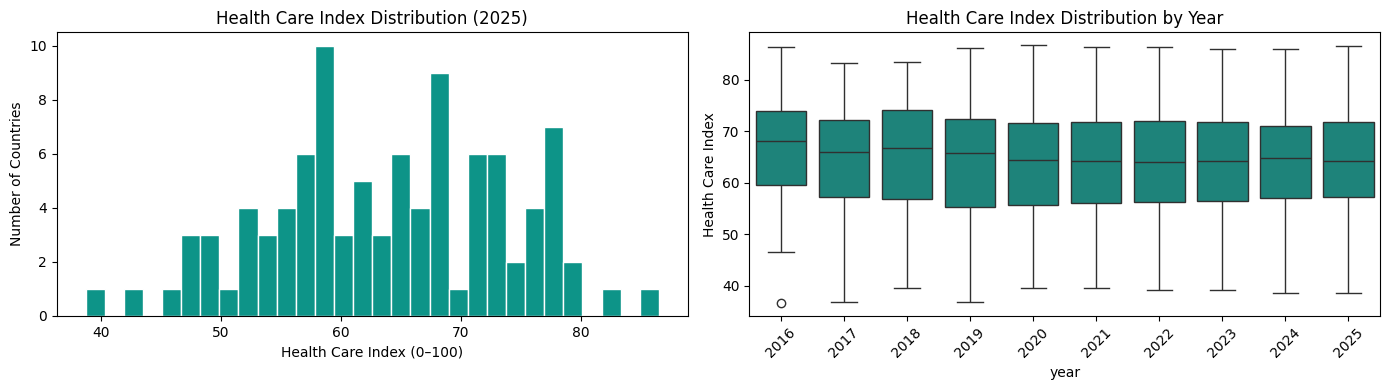

In [9]:
# Distribution of Health Care Index in the latest year
latest = df[df['year'] == df['year'].max()]
print(f'Health Care Index summary ({latest_year}):')
print(latest['Health Care Index'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(latest['Health Care Index'], bins=30, color='#0D9488', edgecolor='white')
axes[0].set_title(f'Health Care Index Distribution ({latest_year})')
axes[0].set_xlabel('Health Care Index (0–100)')
axes[0].set_ylabel('Number of Countries')

sns.boxplot(data=df, x='year', y='Health Care Index', ax=axes[1], color='#0D9488')
axes[1].set_title('Health Care Index Distribution by Year')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Top and bottom 10 countries in the latest year
print(f'Top 10 countries for healthcare ({latest_year}):')
print(latest.nlargest(10, 'Health Care Index')[['Country', 'Health Care Index']].to_string(index=False))

print(f'\nBottom 10 countries for healthcare ({latest_year}):')
print(latest.nsmallest(10, 'Health Care Index')[['Country', 'Health Care Index']].to_string(index=False))

Top 10 countries for healthcare (2025):
    Country  Health Care Index
     Taiwan               86.5
South Korea               82.8
      Japan               80.0
Netherlands               79.3
    Denmark               78.4
    Austria               77.9
     France               77.7
    Finland               77.5
   Thailand               77.5
      Spain               77.3

Bottom 10 countries for healthcare (2025):
   Country  Health Care Index
 Venezuela               38.7
Bangladesh               42.2
      Iraq               45.9
   Morocco               46.8
     Egypt               47.3
   Albania               48.2
Azerbaijan               48.3
   Belarus               48.5
   Nigeria               49.1
  Cambodia               50.7


In [11]:
# Full country league table for the latest year (ranked by Health Care Index)
country_latest = latest[['Country', 'Health Care Index']].sort_values('Health Care Index', ascending=False)

print(f'Top 15 countries by healthcare index ({latest_year}):')
print(country_latest.head(15).round(2).to_string(index=False))

print(f'\nBottom 15 countries ({latest_year}):')
print(country_latest.tail(15).round(2).to_string(index=False))

Top 15 countries by healthcare index (2025):
       Country  Health Care Index
        Taiwan               86.5
   South Korea               82.8
         Japan               80.0
   Netherlands               79.3
       Denmark               78.4
       Austria               77.9
        France               77.7
       Finland               77.5
      Thailand               77.5
         Spain               77.3
       Ecuador               77.1
       Belgium               75.9
        Norway               75.6
Czech Republic               75.5
       Estonia               75.5

Bottom 15 countries (2025):
   Country  Health Care Index
   Hungary               54.3
      Iran               52.8
     Malta               52.5
    Serbia               52.1
   Ireland               51.5
  Cambodia               50.7
   Nigeria               49.1
   Belarus               48.5
Azerbaijan               48.3
   Albania               48.2
     Egypt               47.3
   Morocco            

In [12]:
# Trend in mean Health Care Index over time — weight by whether the SAME countries are reporting.
# Use the balanced panel (countries present in every year) to strip out sample-change effects.
balanced = df.groupby('Country').filter(lambda g: g['year'].nunique() == df['year'].nunique())
print(f'Balanced panel: {balanced["Country"].nunique()} countries across all years')

trend = (
    df.groupby('year')['Health Care Index'].mean().rename('all_countries')
      .to_frame()
      .join(balanced.groupby('year')['Health Care Index'].mean().rename('balanced_panel'))
)
print('\nMean healthcare index over time:')
print(trend.round(2).to_string())

fig = px.line(trend.reset_index().melt(id_vars='year', var_name='sample', value_name='mean_index'),
              x='year', y='mean_index', color='sample', markers=True,
              title='Mean Health Care Index Over Time — All Countries vs Balanced Panel',
              labels={'mean_index': 'Mean Health Care Index', 'sample': 'Sample'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

Balanced panel: 61 countries across all years

Mean healthcare index over time:
      all_countries  balanced_panel
year                               
2016          66.31           65.81
2017          64.88           65.84
2018          65.41           65.91
2019          64.14           65.69
2020          63.42           65.74
2021          63.68           66.21
2022          63.56           66.34
2023          63.78           66.35
2024          63.82           66.17
2025          63.94           66.40


In [13]:
# Cross-compare with cost of living — is there a sweet-spot cluster (high healthcare, low cost)?
col = pd.read_csv('../data/clean/numbeo_cost_of_living_country_clean.csv')
merged = pd.merge(
    df[['Country', 'year', 'Health Care Index']],
    col[['Country', 'year', 'Cost of Living Index']],
    on=['Country', 'year'], how='inner'
)
merged_latest = merged[merged['year'] == latest_year].dropna()
print(f'Countries matched in {latest_year}: {len(merged_latest)}')

r, p = stats.pearsonr(merged_latest['Cost of Living Index'], merged_latest['Health Care Index'])
print(f'Correlation (cost of living vs healthcare): r = {r:.3f}, p = {p:.4f}')

fig = px.scatter(merged_latest, x='Cost of Living Index', y='Health Care Index',
                 hover_name='Country', trendline='ols',
                 title=f'Health Care Index vs Cost of Living Index ({latest_year}) — r = {r:.3f}',
                 labels={'Cost of Living Index': 'Cost of Living Index',
                         'Health Care Index': 'Health Care Index'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

Countries matched in 2025: 97
Correlation (cost of living vs healthcare): r = 0.514, p = 0.0000


In [14]:
# Candidate sweet-spot countries: above-median healthcare AND below-median cost
med_h = merged_latest['Health Care Index'].median()
med_c = merged_latest['Cost of Living Index'].median()
sweet = merged_latest[(merged_latest['Health Care Index'] > med_h) &
                      (merged_latest['Cost of Living Index'] < med_c)].copy()
sweet['value_ratio'] = sweet['Health Care Index'] / sweet['Cost of Living Index']
print(f'Sweet-spot candidate countries ({latest_year}): {len(sweet)}')
print('\nTop 15 by healthcare/cost ratio:')
print(sweet.nlargest(15, 'value_ratio')[['Country', 'Health Care Index', 'Cost of Living Index', 'value_ratio']].round(2).to_string(index=False))

Sweet-spot candidate countries (2025): 13

Top 15 by healthcare/cost ratio:
    Country  Health Care Index  Cost of Living Index  value_ratio
      India               65.5                  19.5         3.36
   Colombia               68.6                  26.0         2.64
    Ecuador               77.1                  30.0         2.57
   Malaysia               70.3                  29.7         2.37
Philippines               67.3                  28.8         2.34
   Thailand               77.5                  33.7         2.30
      China               68.7                  30.7         2.24
  Sri Lanka               71.4                  33.5         2.13
     Mexico               72.5                  34.5         2.10
     Turkey               71.2                  34.7         2.05
  Argentina               68.0                  35.7         1.90
  Guatemala               67.3                  36.8         1.83
     Jordan               65.2                  37.2         1.75


In [15]:
# Country-level choropleth. Numbeo gives us country names, not ISO codes,
# so we use plotly's locationmode='country names'.
country_map = latest[['Country', 'Health Care Index']]
fig = px.choropleth(
    country_map,
    locations='Country', locationmode='country names',
    color='Health Care Index', hover_name='Country',
    color_continuous_scale='Teal',
    title=f'Numbeo Health Care Index by Country ({latest_year})',
    labels={'Health Care Index': 'Health Care Index'}
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()